### Libraries and Imports


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from datetime import date
%matplotlib inline
import re
import glob
import matplotlib as mpl
import matplotlib.animation as animation

### PDE and FD reference Parameters and RL action space


In [5]:
# PDE 
alpha = 0.05

#   FD reference grid   
nx    = 100
T     = 1
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

#  True solution; Analytical diffusion solution

def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

 

### FD For diffusion

In [6]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
            bounds_error=False, fill_value=None
    )
    return u, interp

### __ init __

In [7]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every
        self._idx_set       = set()               
        self.rejected_history = []  # (x, t) per rejected move
    def add(self, x, t, u):
        self._idx_set.add((round(x / dx), round(t / dt)))  
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()
    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0
    def contains(self, x, t):                    
        return (round(x / dx), round(t / dt)) in self._idx_set
    def find_neighbours(self, x_star, t_star, n):
        if len(self._pts) < n:
            return None
        pts_arr  = np.asarray(self._pts)
        norm_arr = np.asarray(self._norm)

        # causal filter: neighbours at or before the query time
        mask = pts_arr[:, 1] <= t_star

        # a point can never be its own neighbour: exclude the exact query cell
        same_cell = (np.round(pts_arr[:, 0] / dx) == round(x_star / dx)) & \
                    (np.round(pts_arr[:, 1] / dt) == round(t_star / dt))
        mask &= ~same_cell

        if mask.sum() < n:
            return None
        norm_c = norm_arr[mask]
        pts_c  = pts_arr[mask]
        target = np.array([x_star / dx, t_star / dt])
        d2     = np.sum((norm_c - target) ** 2, axis=1)
        idx = np.argpartition(d2, n - 1)[:n]
        idx = idx[np.argsort(d2[idx])]
        return [tuple(row) for row in pts_c[idx]]

    def __len__(self):
            return len(self._pts)

### GFDM Solver


In [8]:
def solve_weights(dx_i, dt_i):
    h = max(np.max(np.abs(dx_i)), np.sqrt(alpha * np.max(np.abs(dt_i))), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    #cond = np.linalg.cond(A)
    #if cond > 1e4:
    #    return None, 'cond'

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    #if np.max(np.abs(w)) > 3.0 / len(dx_i):
    #    return None, 'weights'
    #if np.min(w) < -1.0:
    #    return None, 'weights'

    return w, 'ok'

### PDEEnvironment

In [9]:
from logging import info


class PDEEnvironment(gym.Env):
    ACTIONS = {0: (-1, 1),
               1: ( 0, 1),
               2: ( 1, 1)}
    
    def __init__(self, t_star_schedule=None, t_star_steps=2, N_particles=27,
             err_tol=1e-3, w_err=0.8, w_time=0.2,
             K_max=5000, c_shape=0.05,
             x_star_schedule=None):
        super().__init__()

        self.alpha = alpha
        self.c_shape = c_shape
        self.ERR_CEIL = 2.2
        self.R_REACH = 0.2
        self.nx = nx; self.nt = nt
        self.x_fd = x_fd; self.t_fd = t_fd
        self.dx = dx; self.dt = dt; self.T = T

        self.t_star_schedule = dict(t_star_schedule) if t_star_schedule else None

        # ── x* schedule: list of grid indices to sample from. None → fixed center.
        # Store as x_fd values so x* always lands on the grid.
        if x_star_schedule is not None:
            self.x_star_choices = np.array(
                [self.x_fd[int(ix)] for ix in x_star_schedule], dtype=float)
        else:
            self.x_star_choices = None

        # ── Target point (z*) ──
        self.x_star = self.x_fd[self.nx // 2]     # provisional; reset() may override
        self.t_star_steps = t_star_steps
        self.t_star = t_star_steps * dt

        self.K_max = K_max
        self.err_tol = err_tol
        self.w_err = w_err
        self.w_time = w_time
        self.phi_scale = 1.0
        self.n_neighbours = 5
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        # ── Walker initial positions: FROZEN to domain center, INDEPENDENT of x* ──
        self.N = N_particles
        mid = self.nx // 2
        margin = 2
        half_n = self.N // 2
        step = (mid - margin) / half_n if half_n > 0 else 0
        offsets = [0]; k = 1
        while len(offsets) < self.N:
            offsets.append(k * step)
            if len(offsets) < self.N:
                offsets.append(-k * step)
            k += 1
        init_idx = np.clip(
            np.round(np.array(offsets[:self.N]) + mid).astype(int),
            margin, self.nx - 1 - margin)
        self.walker_init_x = self.x_fd[init_idx]   # does NOT depend on x_star

        _, self.fd_interp = build_fd_reference()

        self.visited = None
        self.walker_x = None
        self.walker_t = None
        self.walker_u = None
        self.step_count = 0
        self.stencil_log = {}

        # obs: 2N relative coords + t*_norm + x*_norm  → 2N+2
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(2 * self.N + 2,), dtype=np.float32)
        self.action_space = spaces.Discrete(self.N * len(self.ACTIONS))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        if self.t_star_schedule is not None:
            choices = list(self.t_star_schedule.keys())
            self.t_star_steps = int(self.np_random.choice(choices))
            self.t_star = self.t_star_steps * self.dt
            self.K_max = self.t_star_schedule[self.t_star_steps]

        # ── Resample x* per episode if a schedule is set ──
        if self.x_star_choices is not None:
            self.x_star = float(self.np_random.choice(self.x_star_choices))

        self.visited = VisitedSet()
        self.stencil_log = {}

        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        self.walker_x = np.array(self.walker_init_x, dtype=float)
        self.walker_t = np.zeros(self.N)
        self.walker_u = np.array([u_true(x, 0.0) for x in self.walker_x])
        self.step_count = 0
        self.rejected_history = []
        self.gfdm_rejected_set = set()
        self.phi_scale = max(self._mean_target_distance(), 1e-12)
        self._phi_prev = self._potential()

        return self._build_obs(), {}

    def _build_obs(self):
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        t_star_norm = self.t_star / self.dt          # horizon length in step units
        x_star_norm = self.x_star / self.dx          # NEW: absolute x* in dx units
        return np.array([
            *dx_rel,
            *dt_rel,
            t_star_norm,
            x_star_norm,
        ], dtype=np.float32)

    def _mean_target_distance(self):
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        d = np.sqrt(dx_rel**2 + dt_rel**2)
        return float(np.min(d))

    def _potential(self):
        if self.c_shape == 0.0:
            return 0.0
        return -self.c_shape * self._mean_target_distance() / max(self.phi_scale, 1e-12)

    def _gfdm_solve(self, x_star, t_star):
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False, None, 'no_nb'
        nb = np.array(nb)
        dx_i = nb[:, 0] - x_star
        dt_i = nb[:, 1] - t_star
        w, reason = solve_weights(dx_i, dt_i)
        if w is None:
            return None, False, None, reason
        u_hat = float(w @ nb[:, 2])
        if abs(u_hat) > 1.1:
            return None, False, None, 'bounds_u'
        return u_hat, True, nb[:, :2], 'ok'

    def step(self, action):
        self.step_count += 1
        done = False
        reward = 0.0

        i = int(action) // len(self.ACTIONS)
        j = int(action) % len(self.ACTIONS)
        dx_idx, dt_idx = self.ACTIONS[j]
        dx_move = dx_idx * self.dx
        dt_move = dt_idx * self.dt

        info = {'walker': i, 'accepted': False, 'rejected': None, 'reached': False}

        x_new = self.walker_x[i] + dx_move
        t_new = self.walker_t[i] + dt_move

        if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
            info['rejected'] = 'bounds'
        elif self.visited.contains(x_new, t_new):
            info['rejected'] = 'collision'
        else:
            u_hat, success, nb_coords, reason = self._gfdm_solve(x_new, t_new)
            if not success:
                info['rejected'] = reason
                self.gfdm_rejected_set.add(int(action))
            else:
                self.gfdm_rejected_set.clear()
                self.visited.add(x_new, t_new, u_hat)
                self.walker_x[i] = x_new
                self.walker_t[i] = t_new
                self.walker_u[i] = u_hat
                self.stencil_log[(round(x_new, 8), round(t_new, 8))] = nb_coords
                info['accepted'] = True
                if (abs(x_new - self.x_star) < self.eps_x and
                        abs(t_new - self.t_star) < self.eps_t):
                    done = True
                    info['reached'] = True

        if not info['accepted']:
            self.rejected_history.append((x_new, t_new, info['rejected']))
        
        if done:
            u_pred, _, _, _ = self._gfdm_solve(self.x_star, self.t_star)
            u_ref = u_true(self.x_star, self.t_star)
            if u_pred is None:
                reward = -1.0 - self.w_time
                info['error'] = None
            else:
                err = abs(u_pred - u_ref)
                err_norm = float(np.clip(
                    np.log10(max(err, 1e-12) / self.err_tol) / 3.0, 0.0, 1.0))
                time_norm = self.step_count / max(self.K_max, 1)

                r_acc = -self.w_err * err_norm
                r_eff = -self.w_time * time_norm

                reward = self.R_REACH + r_acc + r_eff
                
                
                info['u_pred'] = u_pred
                info['u_ref']  = u_ref
                info['error']  = err
                info['k_term'] = self.step_count
                info['err_norm'] = err_norm
                info['time_norm'] = time_norm   
                info['r_acc']  = r_acc          # log both terms separately —
                info['r_eff']  = r_eff          # you need them for calibration checks
        elif (self.step_count >= self.K_max or
              np.all(self.walker_t >= self.t_star - self.eps_t)):
            done = True
            reward = -1.0 - self.w_time
            info['timeout'] = True

        phi_new = 0.0 if done else self._potential()
        shaping = phi_new - self._phi_prev
        self._phi_prev = phi_new
        reward += shaping
        info['shaping'] = shaping
        info['phi'] = phi_new

        return self._build_obs(), reward, done, False, info

    def action_masks(self) -> np.ndarray:
        mask = np.ones(self.N * len(self.ACTIONS), dtype=bool)
        for i in range(self.N):
            for j in range(len(self.ACTIONS)):
                dx_idx, dt_idx = self.ACTIONS[j]
                x_new = self.walker_x[i] + dx_idx * self.dx
                t_new = self.walker_t[i] + dt_idx * self.dt
                if not (0.0 <= x_new <= 1.0 and
                        0.0 < t_new <= self.t_star + self.eps_t and
                        not self.visited.contains(x_new, t_new)):
                    mask[i * len(self.ACTIONS) + j] = False
        for a in self.gfdm_rejected_set:
            mask[a] = False
        if not mask.any():
            mask[:] = True
        return mask

### Sanity Check: Random Policy Baseline

Steps:          2000
Reward:         -1.195757
Reached:        False
Timeout:        True
Total accepted: 1773
Total rejected: 227
Rejection reasons:
  collision : 220
  bounds    : 5
  bounds_u  : 2

Accepted moves per walker:
  Walker 0: 67
  Walker 1: 76
  Walker 2: 66
  Walker 3: 67
  Walker 4: 42
  Walker 5: 73
  Walker 6: 53
  Walker 7: 76
  Walker 8: 74
  Walker 9: 47
  Walker 10: 76
  Walker 11: 68
  Walker 12: 62
  Walker 13: 75
  Walker 14: 51
  Walker 15: 54
  Walker 16: 75
  Walker 17: 59
  Walker 18: 80
  Walker 19: 85
  Walker 20: 47
  Walker 21: 72
  Walker 22: 58
  Walker 23: 53
  Walker 24: 68
  Walker 25: 84
  Walker 26: 65


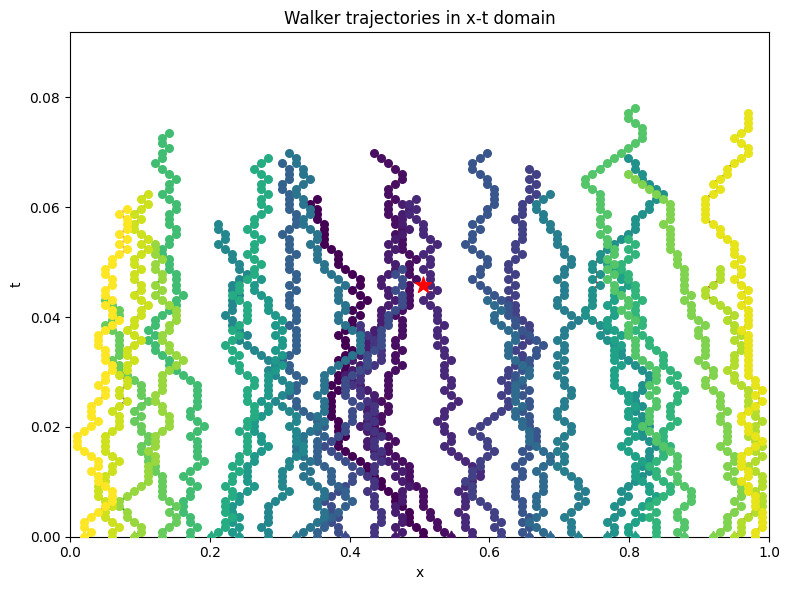

In [10]:
K_max= 2000
t_star_steps = 50  # ← change this to test different targets
env      = PDEEnvironment(t_star_steps=t_star_steps, K_max=K_max)
state, _ = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    action = env.action_space.sample()
    state, reward, done, _, info = env.step(action)



    total_accepted += int(info['accepted'])
    if info['rejected']:
        reason = info['rejected']
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts
               if t > 0.0 and 0.0 < x < 1.0]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Total rejected: {sum(total_rejected.values())}")
print("Rejection reasons:")

for reason, count in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
    print(f"  {reason:10s}: {count}")
# walker distribution check — tells you if one walker is dominating
walker_counts = {}
for i, traj in trajectories.items():
    walker_counts[i] = len(traj) - 1  # subtract starting position
print("\nAccepted moves per walker:")
for i, count in sorted(walker_counts.items()):
    print(f"  Walker {i:d}: {count}")

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = plt.cm.viridis(np.linspace(0, 1, env.N))
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

## Plot Trajactories


In [11]:
def plot_trajectories(model, t_star_steps, N_particles, err_tol, w_err, w_time, K_max, c_shape,
                      save=True, timestep=None, img_dir=".", label=None,
                      x_star_steps=None):          # NEW: grid index for x*; None → center
    env = PDEEnvironment(t_star_steps=t_star_steps, N_particles=N_particles,
                         err_tol=err_tol, w_err=w_err, w_time=w_time, K_max=K_max, c_shape=c_shape,
                         x_star_schedule=None if x_star_steps is None else [x_star_steps])
    obs, _ = env.reset()
    trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True, action_masks=env.action_masks())
        obs, reward, done, _, info = env.step(action)
        if info['accepted']:
            i = info['walker']
            trajectories[i].append((env.walker_x[i], env.walker_t[i]))

    visited_log = [(x, t) for (x, t, _) in env.visited._pts]
    fig, ax = plt.subplots(figsize=(8, 6))

    vx = [p[0] for p in visited_log]
    vt = [p[1] for p in visited_log]
    ax.scatter(vx, vt, s=4, color='lightgray', zorder=1)

    # ── Rejected positions ───────────────────────────────────────────────────
    rej_colors = {
        'bounds':    'blue',
        'collision': 'orange',
        'cond':      'purple',
        'weights':   'brown',
        'geometry':  'red',
        None:        'gray',
    }
    if env.rejected_history:
        from collections import defaultdict
        by_reason = defaultdict(list)
        for (rx, rt, reason) in env.rejected_history:
            by_reason[reason].append((rx, rt))
        for reason, pts in by_reason.items():
            ax.scatter([p[0] for p in pts], [p[1] for p in pts],
                       s=6, alpha=0.08, linewidths=0, zorder=1,
                       color=rej_colors.get(reason, 'gray'),
                       label=f'rej:{reason} ({len(pts)})')
    # ─────────────────────────────────────────────────────────────────────────

    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    for i, traj in trajectories.items():
        xs = [p[0] for p in traj]
        ts = [p[1] for p in traj]
        ax.plot(xs, ts, '-', linewidth=1.5, color=colors[i], zorder=2)
        ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
        ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^', zorder=4)

    reached = info.get('reached', False)
    outcome = 'reached' if reached else 'timeout'

    # ── Stencil at z* ────────────────────────────────────────────────────────
    if reached:
        _, success, nb_coords, _ = env._gfdm_solve(env.x_star, env.t_star)
        if success and nb_coords is not None:
            for (nx_, nt_) in nb_coords:
                ax.plot([env.x_star, nx_], [env.t_star, nt_],
                        '--', color='red', linewidth=0.8,
                        alpha=0.7, zorder=5)
            ax.scatter(nb_coords[:, 0], nb_coords[:, 1],
                       s=40, color='red', zorder=6, alpha=0.7)

    ax.scatter(env.x_star, env.t_star, s=150, color='red', marker='*', zorder=7)
    ax.set_xlabel('x')
    ax.set_ylabel('t')

    title = f't_star={t_star_steps}·dt  |  x_star={env.x_star:.2f}  |  {outcome}'
    if timestep is not None:
        title += f'  |  step {timestep:,}'
    if reached and info.get('error') is not None:
        title += f'  |  err={info["error"]:.2e}  |  k={info["k_term"]}'
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, env.t_star * 2)

    if env.rejected_history:
        ax.legend(fontsize=6, loc='upper left', markerscale=2)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.6, zorder=0)
    plt.tight_layout()

    if save:
        xtag = "" if x_star_steps is None else f"_x{x_star_steps}"

        if label is not None:
            fname = f'traj_t{t_star_steps}dt{xtag}_{label}_{outcome}.png'
        elif timestep is not None:
            fname = f'traj_t{t_star_steps}dt{xtag}_{timestep//1000:05d}k_{outcome}.png'
        else:
            fname = f'traj_t{t_star_steps}dt{xtag}_{outcome}.png'
        fig.savefig(os.path.join(img_dir, fname), dpi=120)
        plt.close(fig)
    else:
        plt.show()

In [12]:
class ReachedRateCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.buf       = []
        self.kterm_buf = []
        self.err_buf   = []

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if info.get('reached'):
                self.buf.append(1)
                k = info.get('k_term')
                e = info.get('error')
                if k is not None and e is not None:
                    self.kterm_buf.append(k)
                    self.err_buf.append(e)
            elif info.get('timeout'):
                self.buf.append(0)
        if self.buf:
            self.logger.record('rollout/reached_rate',
                               sum(self.buf[-100:]) / len(self.buf[-100:]))
        if self.kterm_buf:
            self.logger.record('rollout/mean_kterm_on_reach',
                               np.mean(self.kterm_buf[-100:]))
            self.logger.record('rollout/mean_error_on_reach',
                               np.mean(self.err_buf[-100:]))
        return True

In [13]:
class PlotCallback(BaseCallback):
    def __init__(
        self,
        t_star_schedule,
        x_star_schedule,
        N_particles,
        err_tol,
        w_err,
        w_time,
        c_shape,
        plot_freq=50_000,
        img_dir=".",
        verbose=0,
    ):
        super().__init__(verbose)

        self.t_star_schedule = t_star_schedule      # dict: {t*: K_max}
        self.x_star_schedule = x_star_schedule      # list of x* indices

        self.N_particles = N_particles
        self.err_tol = err_tol
        self.w_err = w_err
        self.w_time = w_time
        self.c_shape = c_shape

        self.plot_freq = plot_freq
        self.last_plot_at = 0
        self.img_dir = img_dir

    def _on_step(self) -> bool:
        if self.num_timesteps - self.last_plot_at >= self.plot_freq:
            self.last_plot_at = self.num_timesteps

            for t_star_steps, K_max in self.t_star_schedule.items():
                for x_star_steps in self.x_star_schedule:

                    plot_trajectories(
                        self.model,
                        t_star_steps,
                        self.N_particles,
                        self.err_tol,
                        self.w_err,
                        self.w_time,
                        K_max,
                        self.c_shape,
                        save=True,
                        timestep=self.num_timesteps,
                        img_dir=self.img_dir,
                        x_star_steps=x_star_steps,
                    )

        return True


def make_env(t_star_schedule, N_particles, err_tol, w_err, w_time, K_max, c_shape, x_star_schedule):
    def _init():
        env = PDEEnvironment(t_star_schedule=t_star_schedule, N_particles=N_particles,
                             err_tol=err_tol, w_err=w_err, w_time=w_time,
                             K_max=K_max, c_shape=c_shape,
                             x_star_schedule=x_star_schedule)
        env = ActionMasker(env, lambda e: e.action_masks())
        return Monitor(env)
    return _init

In [ ]:
N_particles     = 51
t_star_schedule = {4: 100, 5: 100, 7: 150, 10: 200}   # K_max = 100 * t_star_steps
x_star_schedule = [207,25,35, 50, 65,75,80]  # grid indices for x*; None → fixed center
seeds           = [7]

n_envs          = 12
n_steps         = 1024
batch_size      = 1024

total_timesteps = 50_000_000

err_tol         = 1e-3
w_err           = 1
w_time          = 0.1
c_shape         = 0 
 

# representative t* used ONLY for periodic plots/videos (policy trains on all keys)
plot_tstar   = list(t_star_schedule.keys())[0]  # pick the first t* for plotting
plot_K_max   = t_star_schedule[plot_tstar]
plot_xstar   = x_star_schedule[0]  # representative x* for plots

# ── Run directory ────────────────────────────────────────────────────────────
day        = date.today().day
stages_str = "-".join(str(s) for s in t_star_schedule.keys())
run_name   = f"t{stages_str}_errtol{err_tol}_werr{w_err}_wtime{w_time}_N{N_particles}_c{c_shape}"

run_dir    = os.path.join(f"runs,NEW{day}", run_name)

print(f"Run: {run_dir}")
print(f"Training jointly on t*={list(t_star_schedule.keys())}  "
      f"(periodic plots shown at t*={plot_tstar})")

for seed in seeds:

    seed_dir  = os.path.join(run_dir, f"seed{seed}")
    img_dir   = os.path.join(seed_dir, "images")
    ckpt_dir  = os.path.join(seed_dir, "checkpoints")

    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'#'*50}\nSEED {seed}\n{'#'*50}")

    # every subprocess gets the SAME schedule and resamples t* per episode in reset()
    vec_env = SubprocVecEnv([
        make_env(t_star_schedule, N_particles, err_tol, w_err, w_time, K_max=None,
         c_shape=c_shape, x_star_schedule=x_star_schedule)
        for _ in range(n_envs)
    ])

    model = MaskablePPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        seed=seed,
        tensorboard_log=os.path.join(seed_dir, "logs"),
        learning_rate=2e-4,
        clip_range=0.1,
        n_steps=n_steps,
        batch_size=batch_size,
        gamma=1.0,
        ent_coef=0.01,
        device="cpu",
    )

    print(f"\n{'='*50}")
    print(f"Joint training over t* schedule: {t_star_schedule}")
    print(f"budget: {total_timesteps//1000}k steps")
    print(f"{'='*50}")

    model.learn(
        total_timesteps=total_timesteps,
        reset_num_timesteps=False,
        tb_log_name=f"seed{seed}",
        log_interval=10,
        callback=[
            ReachedRateCallback(),
            PlotCallback(
                t_star_schedule=t_star_schedule,
                x_star_schedule=x_star_schedule,
                N_particles=N_particles,
                err_tol=err_tol,
                w_err=w_err,
                w_time=w_time,
                c_shape=c_shape,
                plot_freq=100_000,
                img_dir=img_dir,
            ),

            CheckpointCallback(
                save_freq=100_000,
                save_path=os.path.join(ckpt_dir, "sched"),
                name_prefix="sched"
            ),
        ],
    )

    model.save(os.path.join(ckpt_dir, "sched_final"))

    # final plots/videos at the representative t*
    plot_trajectories(model, plot_tstar, N_particles, err_tol, w_err, w_time,
                  plot_K_max, c_shape, save=True, timestep=None,
                  img_dir=img_dir, label="final", x_star_steps=plot_xstar)
    make_training_progress_video(img_dir, plot_tstar, N_particles, err_tol, w_err, w_time, plot_K_max, c_shape,
                                 label="final", fps=5)
    make_trajectory_video1(
        model, PDEEnvironment, plot_tstar, N_particles,
        img_dir=img_dir, label="final",
        x_star_steps=plot_xstar,
    )

Run: runs,NEW23\t4-5-7-10_errtol0.001_werr1_wtime0.1_N51_c0
Training jointly on t*=[4, 5, 7, 10]  (periodic plots shown at t*=4)

##################################################
SEED 7
##################################################
Using cpu device

Joint training over t* schedule: {4: 100, 5: 100, 7: 150, 10: 200}
budget: 50000k steps
Logging to runs,NEW23\t4-5-7-10_errtol0.001_werr1_wtime0.1_N51_c0\seed7\logs\seed7_0
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 136          |
|    ep_rew_mean          | -1.05        |
|    mean_error_on_reach  | 4.79e-05     |
|    mean_kterm_on_reach  | 86.1         |
|    reached_rate         | 0.04         |
| time/                   |              |
|    fps                  | 1863         |
|    iterations           | 10           |
|    time_elapsed         | 65           |
|    total_timesteps      | 122880       |
| train/                  |              |
|    approx

Loading: C:\Users\user\OneDrive - American University of Beirut\Desktop\meeting 23,7 figures\sched_9600000_steps.zip


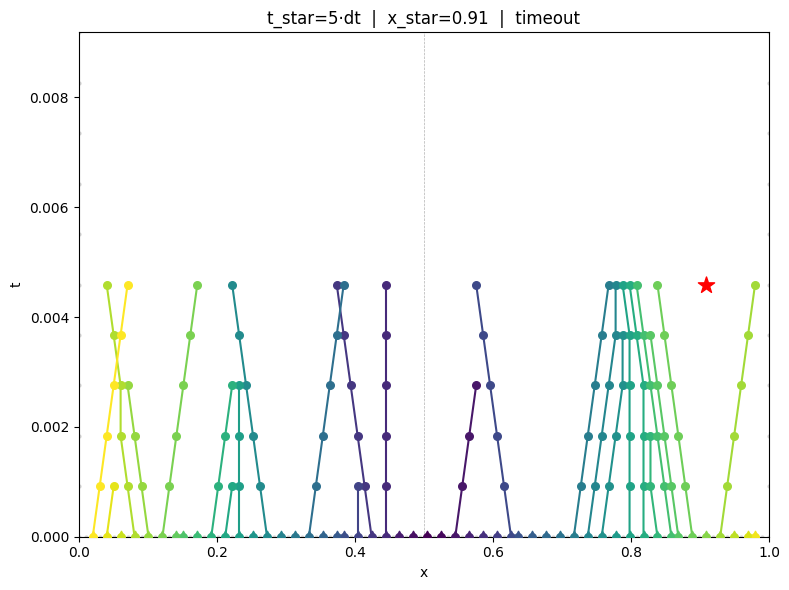

In [21]:
import os, glob, re
from sb3_contrib import MaskablePPO

CKPT_DIR = r"C:\Users\user\OneDrive - American University of Beirut\Desktop\meeting 23,7 figures"

def find_ckpt(which="final"):
    if which == "final":
        p = os.path.join(CKPT_DIR, "sched_final.zip")
        if os.path.exists(p):
            return p
        print("sched_final.zip not found, falling back to latest periodic")
    cands = glob.glob(os.path.join(CKPT_DIR, "**", "*.zip"), recursive=True)
    if not cands:
        raise FileNotFoundError(f"No .zip checkpoints under {CKPT_DIR}")
    def steps(p):
        m = re.search(r"(\d+)_steps", os.path.basename(p))
        return int(m.group(1)) if m else -1
    cands.sort(key=steps)
    return cands[-1]

ckpt_path = find_ckpt("latest")
print("Loading:", ckpt_path)
model = MaskablePPO.load(ckpt_path, device="cpu")

# ── training config (must match the run) ─────────────────────────────────────
N_particles = 51
err_tol     = 1e-3
w_err       = 1
w_time      = 0.1
c_shape     = 0
t_star_schedule = {4: 100, 5: 100, 7: 150, 10: 200}

t_star_steps = 5
x_star_steps = 90

K_max = t_star_schedule.get(t_star_steps, 100 * t_star_steps)

expected = model.observation_space.shape[0]
actual   = 2 * N_particles + 2
assert expected == actual, (
    f"obs mismatch: model expects {expected}, env builds {actual}. "
    f"N_particles or _build_obs differs from the training run."
)

plot_trajectories(
    model, t_star_steps, N_particles, err_tol, w_err, w_time,
    K_max, c_shape,
    save=False,
    timestep=None,
    img_dir=".",
    label=f"eval_t{t_star_steps}_x{x_star_steps}",
    x_star_steps=x_star_steps,
)

In [15]:
# ── output folder: sits next to the run's images/ dir ────────────────────────
seed_dir  = os.path.dirname(CKPT_DIR)                       # ...\seed7
out_dir   = os.path.join(seed_dir, "final images")
os.makedirs(out_dir, exist_ok=True)
print("Saving to:", out_dir)

t_star_schedule = {4: 100, 5: 100, 7: 150, 10: 200}
x_star_schedule = [20, 25, 35, 50, 65, 75, 80]

N_particles = 51
err_tol     = 1e-3
w_err       = 1
w_time      = 0.1
c_shape     = 0

for t_steps, K_max in t_star_schedule.items():
    for x_idx in x_star_schedule:
        plot_trajectories(
            model, t_steps, N_particles, err_tol, w_err, w_time,
            K_max, c_shape,
            save=True, timestep=None, img_dir=out_dir,
            label="eval",
            x_star_steps=x_idx,
        )
        print(f"done  t*={t_steps:2d}  x*_idx={x_idx:2d}")

print(f"\n{len(t_star_schedule) * len(x_star_schedule)} figures written to {out_dir}")

Saving to: C:\Users\user\OneDrive - American University of Beirut\Desktop\final images
done  t*= 4  x*_idx=20
done  t*= 4  x*_idx=25
done  t*= 4  x*_idx=35
done  t*= 4  x*_idx=50
done  t*= 4  x*_idx=65
done  t*= 4  x*_idx=75
done  t*= 4  x*_idx=80
done  t*= 5  x*_idx=20
done  t*= 5  x*_idx=25
done  t*= 5  x*_idx=35
done  t*= 5  x*_idx=50
done  t*= 5  x*_idx=65
done  t*= 5  x*_idx=75
done  t*= 5  x*_idx=80
done  t*= 7  x*_idx=20
done  t*= 7  x*_idx=25
done  t*= 7  x*_idx=35
done  t*= 7  x*_idx=50
done  t*= 7  x*_idx=65
done  t*= 7  x*_idx=75
done  t*= 7  x*_idx=80
done  t*=10  x*_idx=20
done  t*=10  x*_idx=25
done  t*=10  x*_idx=35
done  t*=10  x*_idx=50
done  t*=10  x*_idx=65
done  t*=10  x*_idx=75
done  t*=10  x*_idx=80

28 figures written to C:\Users\user\OneDrive - American University of Beirut\Desktop\final images
